## Entrega del Laboratorio 1 del grupo 11
 Sebastian Vargas Otero - 202323722 
 Juan Diego Ramierez - 20242


En este laboratorio aplicaremos el ciclo de aprendizaje automático para explorar los datos meteorológicos, prepararlos y construir modelos de regresión.

## Importación de librerías

Importaremos las librerías necesarias para cargar, explorar, visualizar y preparar el conjunto de datos.

In [279]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
import sklearn 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error


Cargaremos los datos y trabajaremos con una copia para conservar intacto el archivo original.

## Carga y copia de los datos

Cargaremos el conjunto de entrenamiento y crearemos una copia para realizar el análisis sin modificar directamente los datos originales.

In [280]:
Datos_temperatura = pd.read_csv("./data/Datos Lab 1.csv")
datos = Datos_temperatura.copy()
datos.head()


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,...,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,...,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,...,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,...,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,...,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


Usaremos `info()` para revisar la estructura del conjunto de datos, los tipos de las columnas y la cantidad de valores no nulos.

## Inspección inicial

Revisaremos las primeras filas y la estructura del conjunto para confirmar que los datos se cargaron correctamente.

In [281]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   object 
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv        2497 

Consultaremos el diccionario de datos para comprender el significado de cada variable y orientar las decisiones de preparación.

## Diccionario de datos

Consultaremos el diccionario para comprender el significado de las variables y distinguir entre variables numéricas, categóricas y temporales.

In [282]:
diccionario = pd.read_excel('./data/Diccionario de datos.xlsx')
pd.set_option('display.max_colwidth', None)
diccionario

,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día (mbar).
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


La columna `fecha` se cargó como texto. La convertiremos a un tipo de fecha para poder extraer y comparar el año, el mes y el día del año.

## Conversión de la fecha

Convertiremos `fecha` al tipo de dato fecha para utilizarla en la validación y en la creación de características temporales.

In [283]:
datos["fecha"]=pd.to_datetime(datos["fecha"], format="%Y-%m-%d")
datos["fecha"].head()

0   2009-01-01
1   2009-01-02
2   2009-01-03
3   2009-01-04
4   2009-01-05
Name: fecha, dtype: datetime64[ns]

Después de comprender la estructura de los datos, revisaremos la proporción de valores faltantes en cada columna.

## Valores faltantes

Calcularemos el porcentaje de valores faltantes por columna. Este resultado orientará la estrategia de tratamiento durante la preparación de los datos.

In [284]:
((datos.isnull().sum()/datos.shape[0])*100).sort_values(ascending=False).round(3)

temp_max_manana      3.688
viento_min           3.533
estacion_anio        3.416
mes                  3.416
anio                 3.339
humedad_max          3.339
viento_media         3.339
viento_max           3.144
humedad_min          3.106
viento_norte         3.106
presion_desv         3.106
rafaga_desv          3.067
direccion_viento     3.067
rafaga_media         3.028
registros_del_dia    2.989
presion_media        2.911
presion_min          2.873
humedad_media        2.873
rafaga_max           2.834
rafaga_min           2.795
viento_desv          2.795
fecha                2.795
sector_viento        2.756
dia_del_anio         2.640
presion_max          2.484
viento_este          2.484
humedad_desv         2.368
dtype: float64

Revisaremos las estadísticas descriptivas para conocer los rangos, valores centrales y dispersión de las variables numéricas.

## Estadísticas descriptivas

Analizaremos las principales medidas estadísticas de las variables numéricas para identificar su comportamiento y posibles valores atípicos.

In [285]:
datos.describe()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,2504,2501.000000,2502.000000,2512.000000,2496.000000,2502.000000,2496.000000,2490.000000,2515.000000,2490.000000,...,2504.000000,2503.000000,2497.000000,2496.000000,2512.000000,2497.000000,2499.000000,2490.000000,2508.000000,2481.000000
mean,2012-06-29 14:19:10.159744512,1010.494271,986.684409,991.704244,1.752041,52.413586,45.094067,90.236582,10.606821,3.814103,...,-2.639322,6.946058,-5.763253,-1.128463,-0.410159,172.104573,144.090836,2011.995582,182.690989,13.863309
min,2009-01-01 00:00:00,948.996000,913.600000,951.940000,0.226900,0.004663,0.237700,27.020000,0.000000,0.000000,...,-9999.000000,0.000000,-232.260000,-1250.463300,-3.718500,0.000000,90.000000,2009.000000,1.000000,-15.230000
25%,2010-09-22 18:00:00,984.287800,981.371333,987.070000,0.899050,0.869060,1.011790,88.025000,6.082100,1.655350,...,0.440000,4.803198,1.002100,-1.640625,-1.236475,91.303500,144.000000,2010.000000,91.000000,7.310000
50%,2012-07-04 12:00:00,989.452800,987.070000,991.935000,1.444550,68.558100,49.670000,93.300000,10.199800,2.463400,...,0.660000,6.690000,1.461100,-0.564300,-0.356000,199.568500,144.000000,2012.000000,182.500000,14.310000
75%,2014-03-30 06:00:00,994.469000,992.567500,996.782500,2.254800,80.562600,67.665000,96.600000,14.722200,4.880505,...,1.120000,8.850000,2.008800,0.241525,0.316275,227.101700,144.000000,2014.000000,274.250000,20.460000
max,2015-12-31 00:00:00,9939.918000,1012.320198,1013.940000,12.397500,100.000000,103.311405,100.000000,26.341600,24.753600,...,19.895916,23.500000,3471.027800,4.809900,4.713900,359.796700,287.000000,2015.000000,366.000000,63.050000
std,NaN,435.334494,8.927138,7.726906,1.215931,35.975384,30.196163,10.647237,5.481338,3.307402,...,199.861693,3.237379,75.258134,25.065084,1.147218,86.102348,4.107365,1.999694,105.529469,9.296199


Después de revisar las estadísticas, verificaremos la existencia de registros duplicados.

## Duplicados completos

Verificaremos si existen filas completamente duplicadas. Estos registros podrían repetir exactamente la misma observación y afectar el análisis.

In [286]:
print(f"Existen {datos.duplicated(keep = False).sum()} filas duplicadas en los datos.")

Existen 8 filas duplicadas en los datos.


## Revisión de fechas repetidas

Comprobaremos cuántas filas comparten la misma fecha. Una fecha repetida no implica necesariamente que la fila completa sea un duplicado.

In [287]:
print(f"Existen {datos['fecha'].duplicated(keep = False).sum()} filas con fecha duplicada.")

Existen 108 filas con fecha duplicada.


Revisaremos si existen fechas nulas, ya que una fecha faltante impide validar las características temporales del registro.

## Fechas nulas

Contaremos las fechas faltantes porque una fecha nula impide determinar el año, el mes y el día del año asociados al registro.

In [288]:
datos["fecha"].isnull().sum()

np.int64(72)

## Eliminación de fechas faltantes

Eliminaremos las filas con fecha faltante, porque no es posible reconstruir de forma confiable las características temporales de esos registros.

In [289]:
datos= datos.dropna(subset=['fecha'])
datos["fecha"].isnull().sum()

np.int64(0)

Después de revisar los duplicados completos, inspeccionaremos las filas que tienen fechas repetidas.

## Inspección de fechas repetidas

Mostraremos los registros con fechas repetidas y el número de apariciones de cada fecha. Esto permite distinguir duplicados reales de observaciones diferentes del mismo día.

In [290]:
dup_table = (
    datos[datos['fecha'].duplicated(keep=False)]
    .copy()
    .assign(Repeticiones=datos.groupby('fecha')['fecha'].transform('size'))
    .sort_values(['Repeticiones', 'fecha'], ascending=[False, True])
)
dup_table

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana,Repeticiones
21,2009-01-22,9784.115000,971.48000,983.54,3.9853,86.731100,69.1100,97.6,9.7926,10.09692,...,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770000,2
2563,2009-01-22,9784.115000,971.48000,983.54,3.9853,86.731100,69.1100,97.6,9.7926,10.09692,...,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770000,2
63,2009-03-05,959.860700,958.67000,962.54,0.8964,94.294400,86.0000,97.8,2.8296,1.29080,...,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.370000,2
2574,2009-03-05,959.860700,958.67000,962.54,0.8964,NaN,86.0000,97.8,2.8296,1.29080,...,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.956009,2
121,2009-05-02,998.118900,995.99000,999.41,0.9205,77.500000,51.0900,99.6,18.9020,1.84440,...,0.4668,23.7431,144.0,NaN,122.0,primavera,october,NaN,20.890000,2
2568,2009-05-02,998.855231,995.99000,999.41,0.9205,77.500000,51.0900,99.6,18.9020,1.84440,...,0.4668,23.7431,144.0,2009.0,122.0,primavera,october,NE,20.890000,2
341,2009-12-08,983.849000,979.45000,991.40,3.7836,0.877951,0.8010,96.8,5.9641,4.53492,...,-0.8314,233.2095,144.0,2009.0,342.0,verano,Enero,SO,7.120000,2
2575,2009-12-08,983.849000,979.45000,991.40,3.7836,1.021309,0.8010,96.8,5.9641,4.53492,...,NaN,233.2095,144.0,2009.0,342.0,verano,Enero,SO,7.120000,2
590,2010-08-14,990.482800,989.22000,991.29,0.4346,84.386400,65.1200,95.7,9.4681,1.70860,...,0.6511,39.5952,144.0,2010.0,226.0,verano,August,NE,19.500000,2
2566,2010-08-14,991.272748,989.22000,991.29,0.4346,84.386400,65.1200,95.7,9.4681,1.70860,...,0.6511,39.5952,144.0,2010.0,226.0,verano,August,NE,19.500000,2


## Ajustes de normalizacion de la Humedad

Aca ajustaremos los valores de la humedad ya que algunos estan entre 0-1 y otros enter 1-100, para esto dejaremos todos entre 0-1 como porcentaje

In [291]:
for col in ["humedad_media", "humedad_max", "humedad_min"]:
    datos[col] = datos[col].where(datos[col] <= 1, datos[col] / 100)
    datos[col] = datos[col].clip(upper=1)


## Ajuste de escala de presion

Hay algunos valores de los datos de presion que estan en una escala incorrecta y esta multiplicado por 10, lo cual afecta los datos

In [292]:
for col in ["presion_media", "presion_max", "presion_min"]:
    datos[col] = np.where((datos[col] < 900) | (datos[col] > 1100), np.nan, datos[col])

## Depuración de fechas repetidas

Después de inspeccionar los registros repetidos, conservaremos una sola observación por fecha, asumiendo que el conjunto debe contener una fila diaria. Esta decisión debe justificarse en el análisis.

In [293]:
datos = datos.drop_duplicates(subset=['fecha'], keep='first')

duplicados_restantes = datos['fecha'].duplicated(keep=False).sum()
print(f"Existen {duplicados_restantes} fechas duplicadas después de la limpieza.")

Existen 0 fechas duplicadas después de la limpieza.


## Controles generales de calidad

Realizaremos verificaciones de tipos de datos, valores faltantes, duplicados y rango temporal después de la limpieza inicial.

In [294]:
# Tipos de datos
datos.dtypes

# Valores faltantes
faltantes = datos.isna().sum().sort_values(ascending=False)
faltantes[faltantes > 0]

# Filas completamente duplicadas
datos.duplicated().sum()

# Fechas repetidas
datos["fecha"].duplicated().sum()

# Fechas fuera del rango esperado
datos["fecha"].min(), datos["fecha"].max()

(Timestamp('2009-01-01 00:00:00'), Timestamp('2015-12-31 00:00:00'))

## Detección de valores atípicos

Usaremos diagramas de caja para identificar valores extremos en las variables numéricas. No los eliminaremos automáticamente, porque podrían representar fenómenos meteorológicos reales.

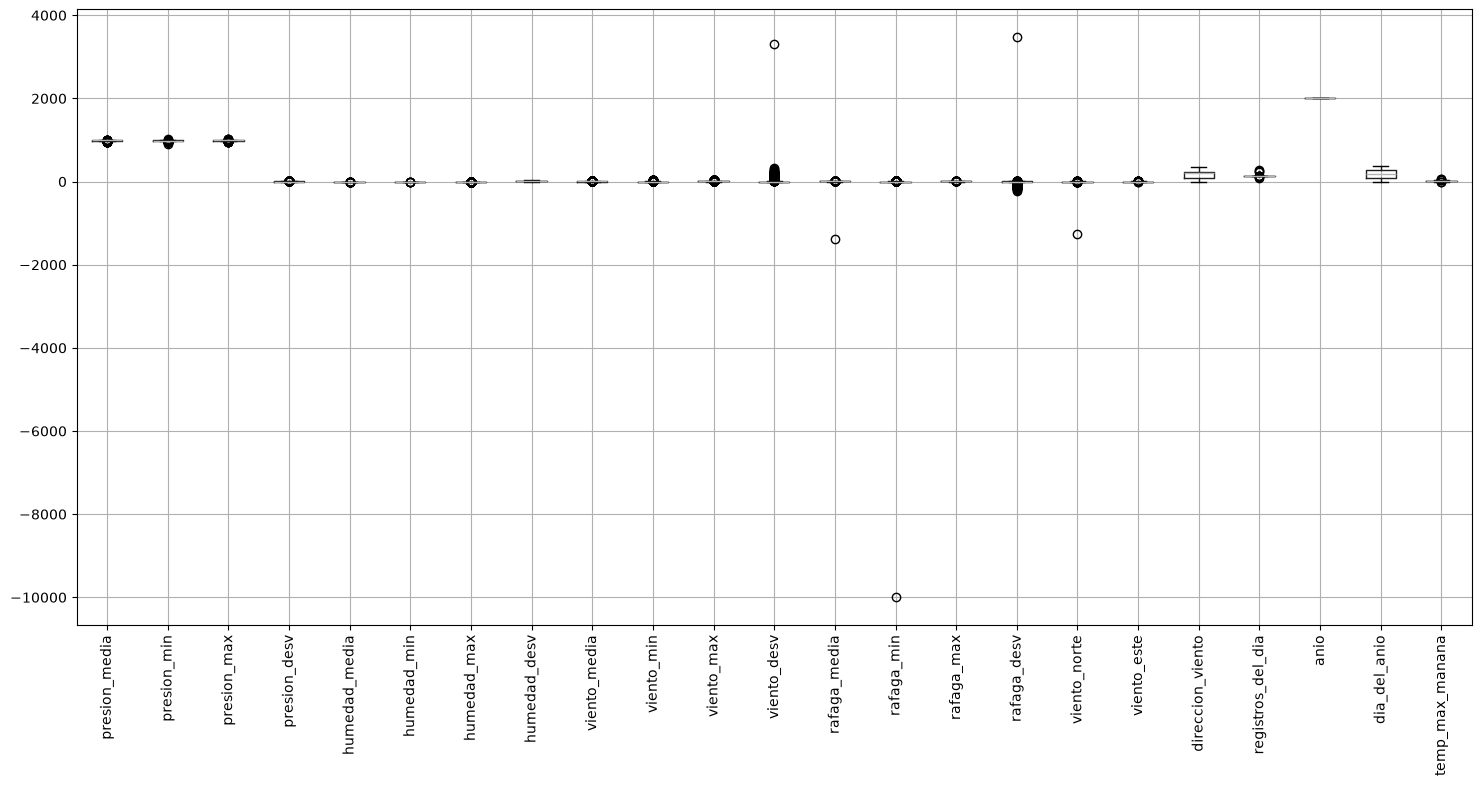

In [295]:
datos.select_dtypes(include="number").boxplot(
    figsize=(18, 8),
    rot=90
)
plt.show()

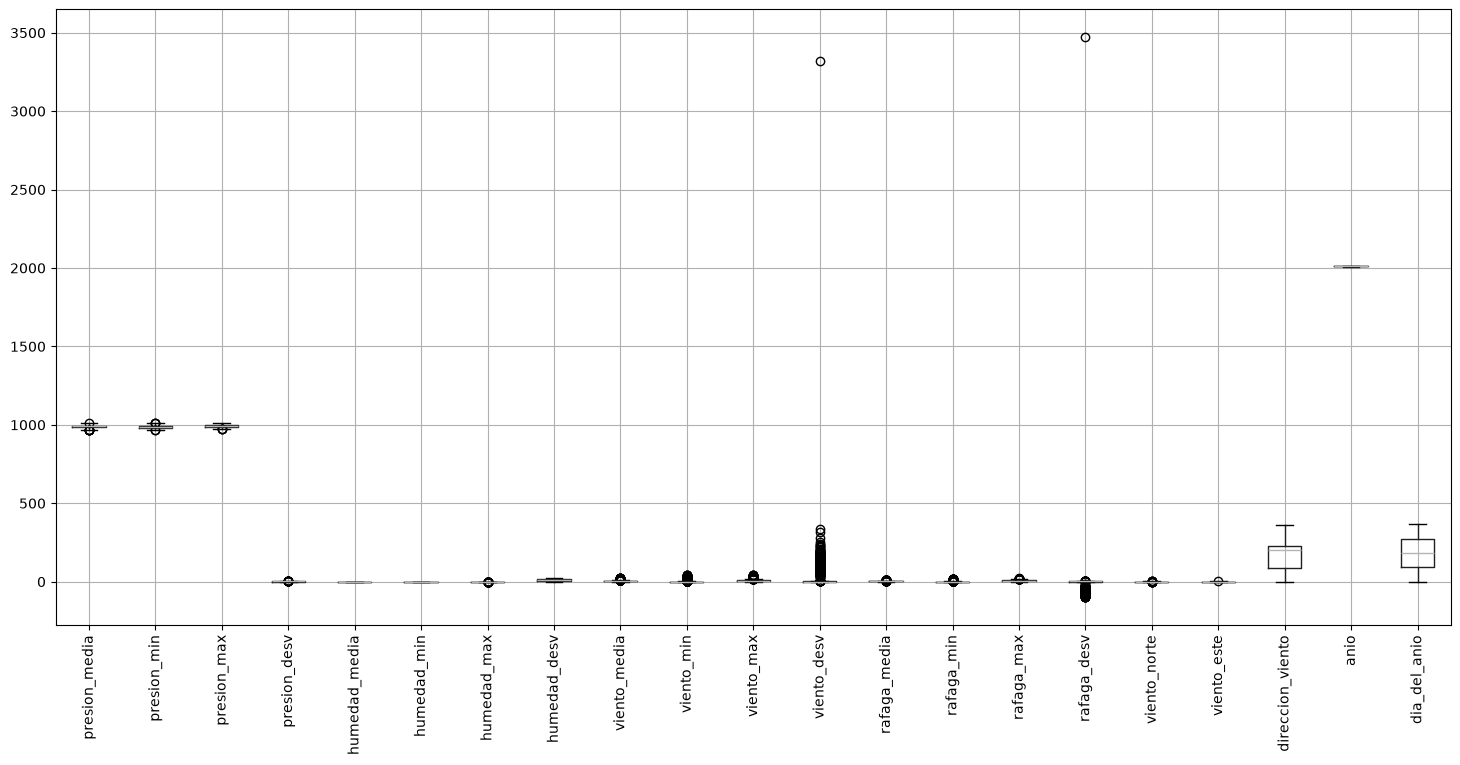

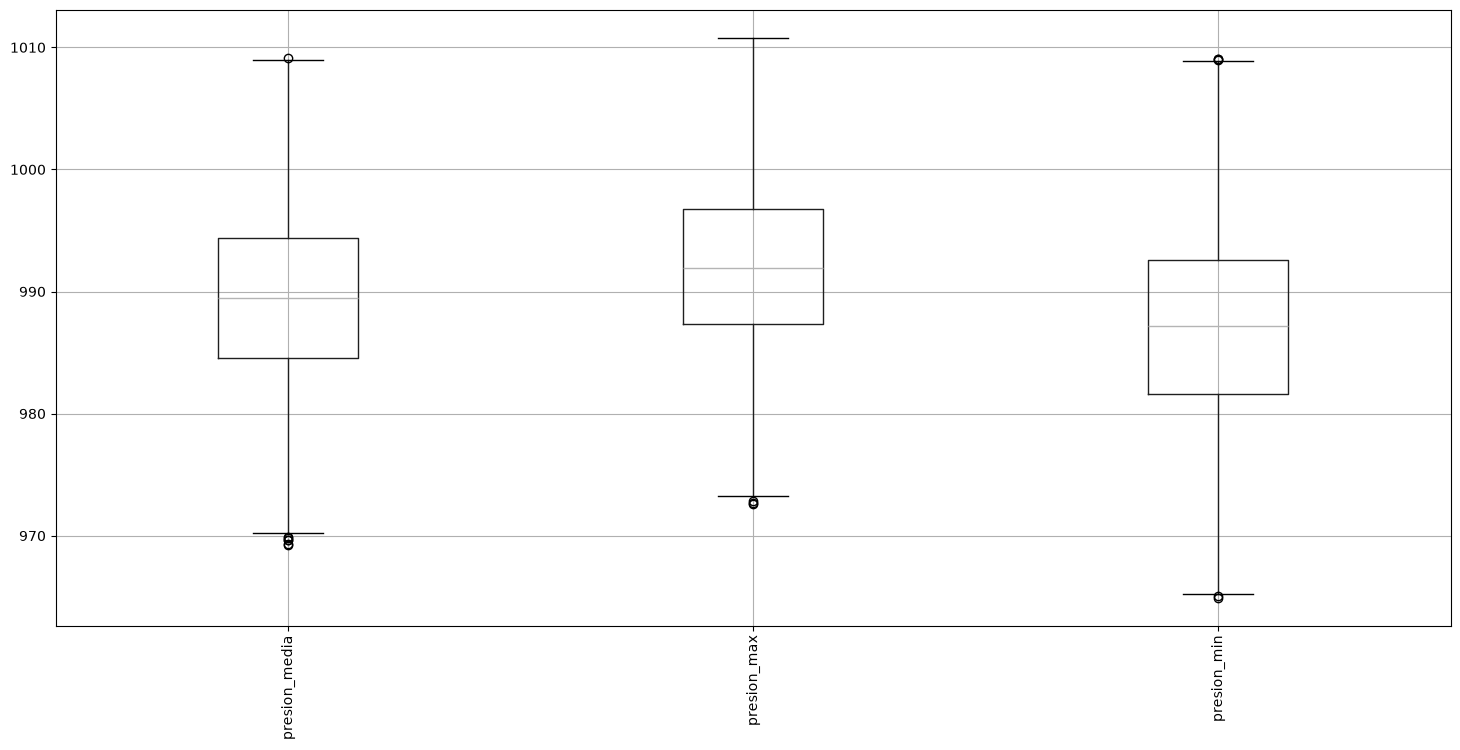

In [296]:
datos_numericos = (
    datos.select_dtypes(include="number")
    .drop(columns=["temp_max_manana", "registros_del_dia"], errors="ignore")
)

cols_viento = [
    "viento_max", "viento_min", "viento_media", "viento_desv",
    "rafaga_media", "rafaga_max", "rafaga_min", "rafaga_desv"
]

for col in cols_viento:
    datos[col] = pd.to_numeric(datos[col], errors="coerce")
    datos.loc[datos[col] <= -100, col] = np.nan

datos_numericos[cols_viento] = datos[cols_viento]

for column in datos_numericos.columns:
    if column in cols_viento:
        continue

    q1 = datos_numericos[column].quantile(0.25)
    q3 = datos_numericos[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    datos_numericos[column] = datos_numericos[column].apply(
        lambda x: x if lower_bound <= x <= upper_bound else None
    )


datos_numericos.select_dtypes(include="number").boxplot(
    figsize=(18, 8),
    rot=90
)
plt.show()

datos[datos_numericos.columns] = datos_numericos


datos.boxplot(
    column=["presion_media", "presion_max", "presion_min"],
    figsize=(18, 8),
    rot=90
)
plt.show()


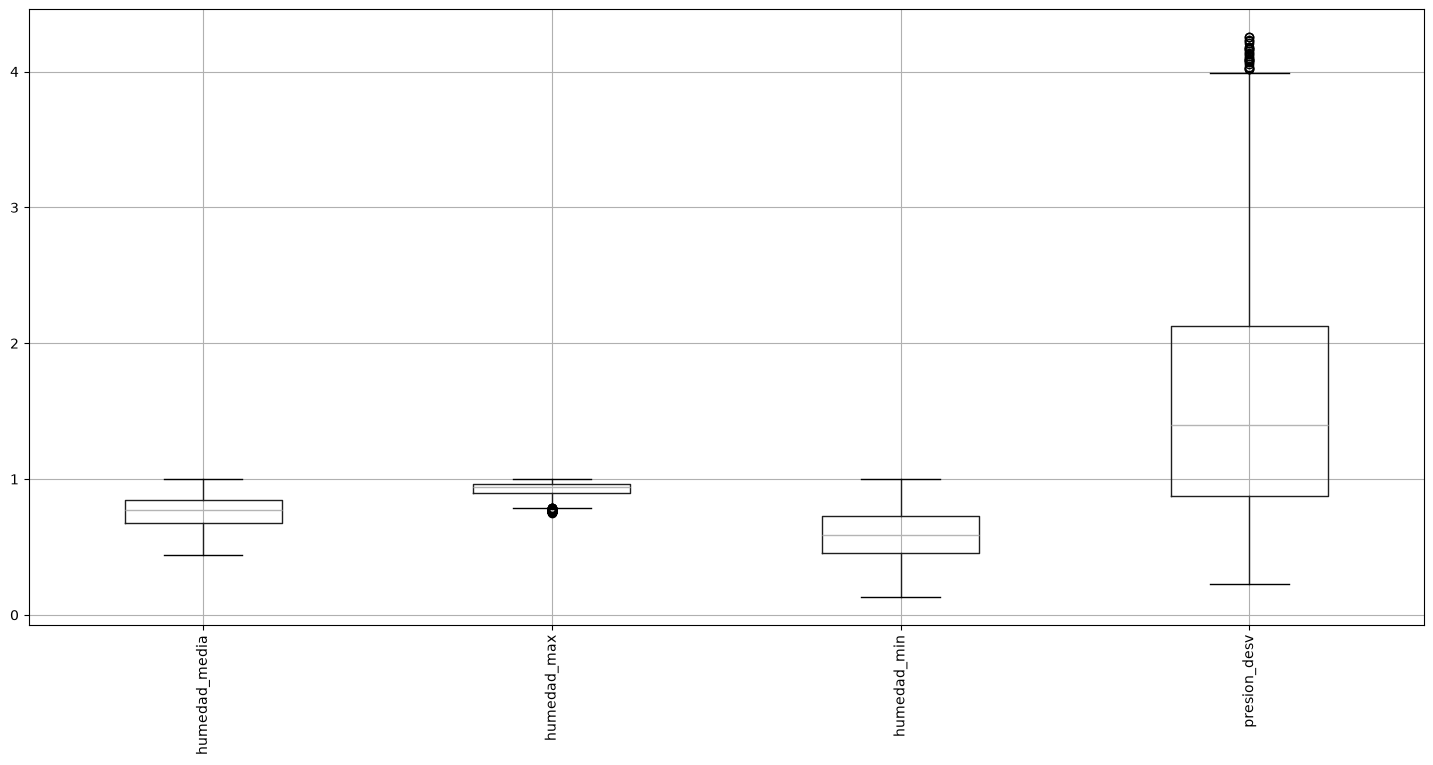

In [297]:
datos.boxplot(
    column=["humedad_media", "humedad_max", "humedad_min","presion_desv"],
    figsize=(18, 8),
    rot=90
)

plt.show()

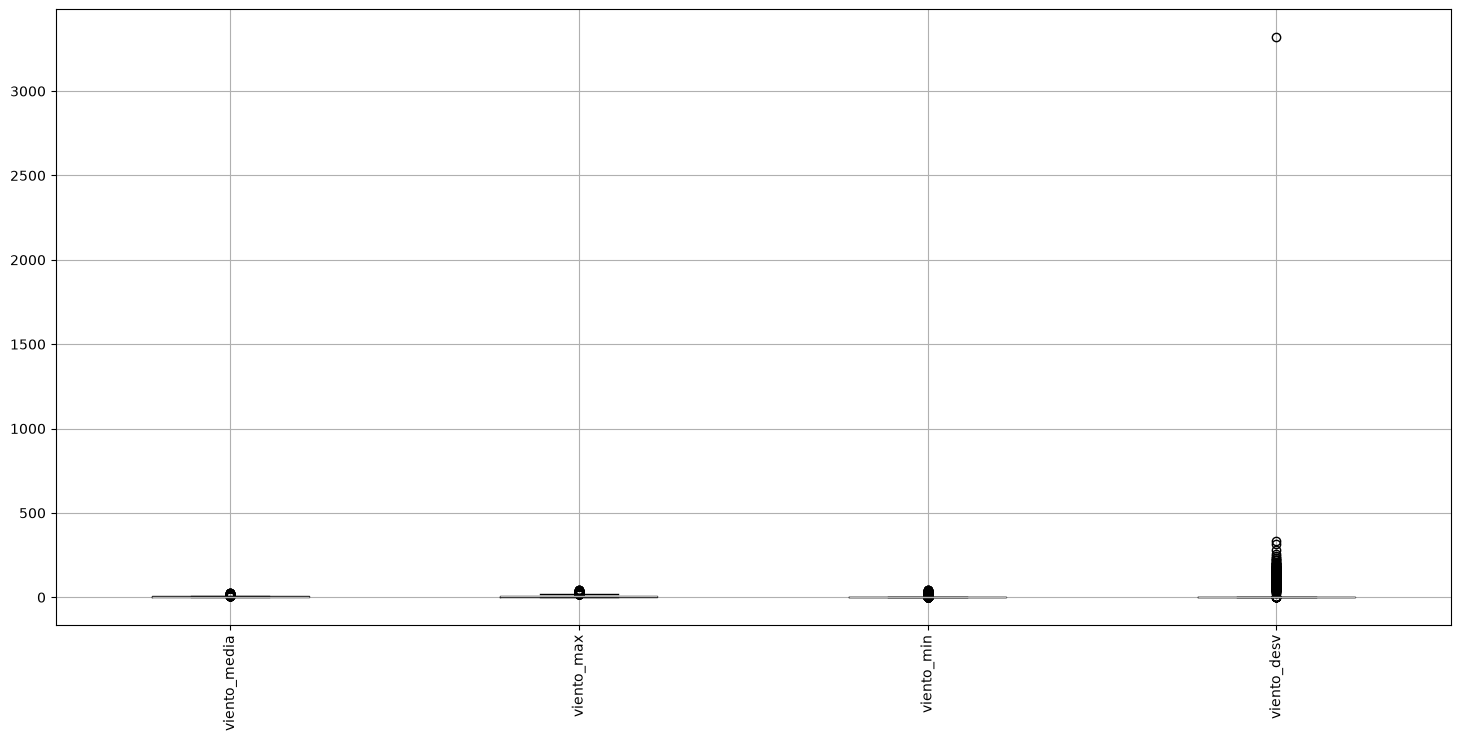

In [298]:
datos.boxplot(
    column=["viento_media", "viento_max", "viento_min","viento_desv"],
    figsize=(18, 8),
    rot=90
)

plt.show()

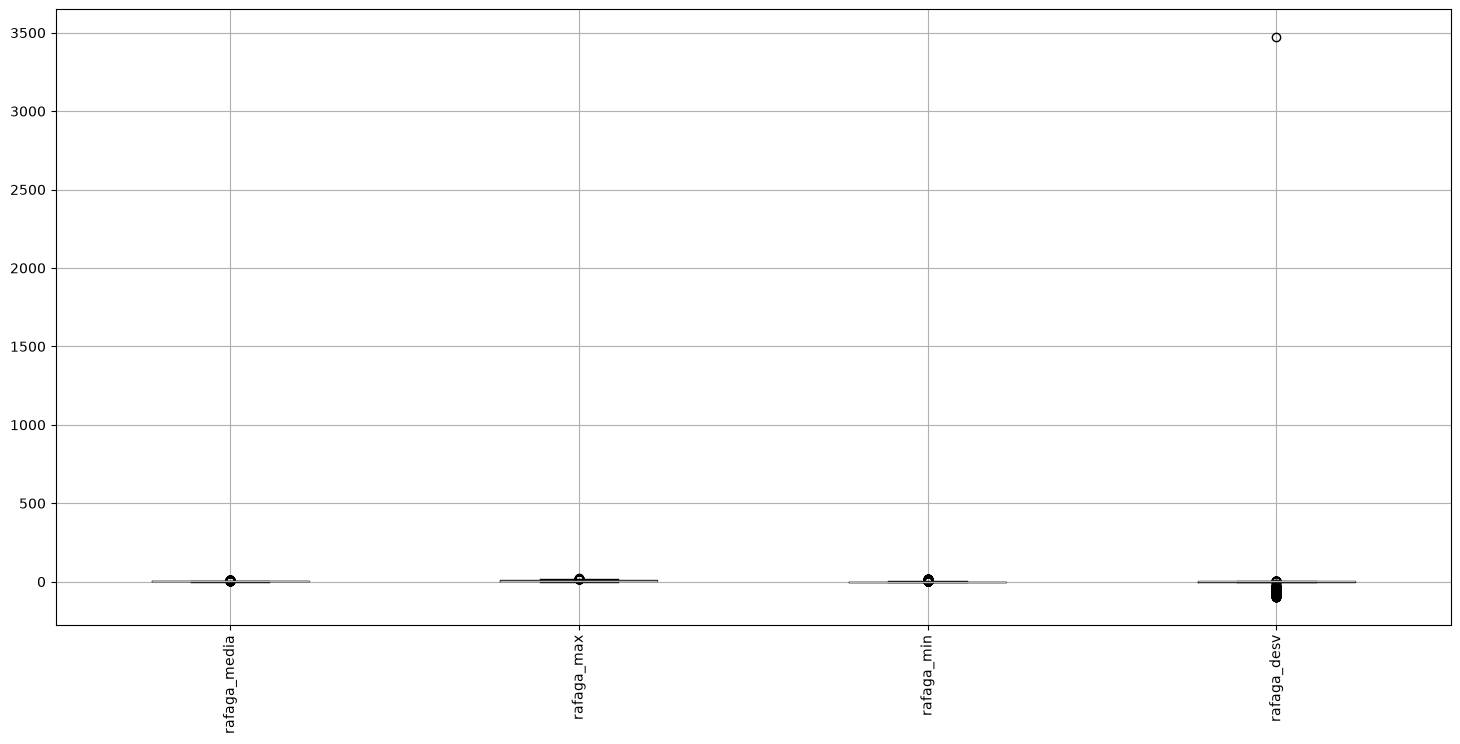

In [299]:
datos.boxplot(
    column=["rafaga_media", "rafaga_max", "rafaga_min","rafaga_desv"],
    figsize=(18, 8),
    rot=90
)

plt.show()

In [300]:
datos.select_dtypes(include="object").nunique()
for columna in datos.select_dtypes(include="object"):
    print(f"\n{columna}:")
    print(datos[columna].value_counts(dropna=False))


estacion_anio:
estacion_anio
primavera               505
invierno                504
otono                   479
verano                  459
NaN                      87
Inverano                 66
Estacion_Desconocida     62
VERANO_INVIERNO          58
East                     48
VERANO                   18
autumn                   17
berano                   17
primaveraa               15
winter                   15
fall                     14
verno                    13
otoño                    11
Otoño                    10
Primavera                10
invierno                  9
Verano                    9
Invierno                  9
PRIMAVERA                 9
invernio                  9
INVIERNO                  8
OTONO                     8
primav                    6
spring                    6
summer                    5
Name: count, dtype: int64

mes:
mes
May        122
July       120
August     119
March      116
January    116
          ... 
junio       16
JANUARY     14
ap

Al revisar las variables temporales y categóricas, identificamos posibles inconsistencias en los años, meses, días, estaciones y sectores del viento. Las corregiremos usando la fecha y las variables relacionadas.

In [301]:
datos["anio"] = datos["fecha"].dt.year
datos["dia_del_anio"] = datos["fecha"].dt.dayofyear

In [302]:
datos["mes"].unique()

array(['January', 'JULY', 'JANUARY', 'May', 'Enero', nan, 'JUNE', 'Sep',
       'April', 'SEPTEMBER', 'noviembre', 'octubre', 'Sept', 'november',
       'april', 'julio', 'February', 'APRIL', 'Aug', 'febrero',
       'septiembre', 'Mar', 'Nov', 'MARCH', 'february', 'November', 'may',
       'july', 'august', 'september', 'July', 'March', 'October', 'junio',
       'october', 'march', 'marzo', 'September', 'Oct', 'DECEMBER', 'Jan',
       'enero', 'NOVEMBER', 'december', 'Jul', 'OCTOBER', 'Jun',
       'diciembre', 'AUGUST', 'June', 'january', 'june', 'Feb', 'August',
       'December', 'agosto', 'Apr', 'mayo', 'abril', 'FEBRUARY', 'MAY',
       'Dec'], dtype=object)

In [303]:
datos["mes"] = datos["fecha"].dt.month_name()
datos["mes"].unique()

array(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October', 'November', 'December'],
      dtype=object)

In [304]:
datos["dia_del_anio"] = datos["fecha"].dt.dayofyear

datos["dia_sin"] = np.sin(2 * np.pi * datos["dia_del_anio"] / 365.25)
datos["dia_cos"] = np.cos(2 * np.pi * datos["dia_del_anio"] / 365.25)

## Tratamiento de valores faltantes

Revisaremos nuevamente los valores faltantes y definiremos una estrategia según el tipo y el significado de cada variable.

In [305]:
datos.isna().sum().sort_values(ascending=False)

humedad_max          236
presion_desv         173
rafaga_desv          159
viento_norte         125
presion_media        117
presion_min          111
humedad_media        100
presion_max           98
temp_max_manana       93
viento_min            88
estacion_anio         87
viento_media          82
viento_max            79
viento_este           78
humedad_min           78
direccion_viento      77
registros_del_dia     77
rafaga_media          77
rafaga_min            71
viento_desv           69
sector_viento         69
rafaga_max            68
humedad_desv          59
fecha                  0
anio                   0
mes                    0
dia_del_anio           0
dia_sin                0
dia_cos                0
dtype: int64

Como `temp_max_manana` es la variable objetivo, eliminaremos los registros que no tienen esta etiqueta, ya que no pueden utilizarse para entrenar el modelo.

In [306]:
datos=datos.dropna(subset=["temp_max_manana"])
datos["temp_max_manana"].isnull().sum()

np.int64(0)

Para las variables numéricas predictoras con valores faltantes, utilizaremos la mediana. Esta medida es menos sensible a los valores atípicos que el promedio.

In [307]:
columnas_numericas = datos.select_dtypes(include="number").columns.drop(
    ["temp_max_manana", "direccion_viento"],
    errors="ignore"
)

medianas_entrenamiento = datos[columnas_numericas].median()
datos[columnas_numericas] = datos[columnas_numericas].fillna(medianas_entrenamiento)

Calcularemos los valores faltantes de `direccion_viento` a partir de las componentes `viento_este` y `viento_norte`, que ya fueron completadas.

In [308]:
direccion_calculada = (
    np.degrees(
        np.arctan2(datos["viento_este"], datos["viento_norte"])
    ) % 360
)

datos["direccion_viento"] = datos["direccion_viento"].fillna(
    direccion_calculada
)

Revisaremos los valores de `estacion_anio` y completaremos los faltantes usando la fecha como fuente de información.

In [309]:
datos["estacion_anio"].unique()

array(['invierno', 'East', nan, 'Estacion_Desconocida', 'verano',
       'Inverano', 'invierno ', 'INVIERNO', 'VERANO_INVIERNO', 'Verano',
       'primavera', 'primaveraa', 'PRIMAVERA', 'berano', 'VERANO',
       'verno', 'otono', 'otoño ', 'fall', 'autumn', 'OTONO', 'winter',
       'invernio', 'Primavera', 'primav', 'spring', 'Otoño', 'Invierno',
       'summer'], dtype=object)

In [310]:
datos["estacion_anio"] = datos["fecha"].dt.month.map({
    1: "invierno",
    2: "invierno",
    3: "primavera",
    4: "primavera",
    5: "primavera",
    6: "verano",
    7: "verano",
    8: "verano",
    9: "otoño",
    10: "otoño",
    11: "otoño", 
    12: "invierno"
})

datos["estacion_anio"].unique()

array(['invierno', 'primavera', 'verano', 'otoño'], dtype=object)

In [311]:
estacion_calculada = datos["fecha"].dt.month.map({
    1: "invierno",
    2: "invierno",
    3: "primavera",
    4: "primavera",
    5: "primavera",
    6: "verano",
    7: "verano",
    8: "verano",
    9: "otoño",
    10: "otoño",
    11: "otoño",
    12: "invierno"
})

datos["estacion_anio"] = datos["estacion_anio"].fillna(estacion_calculada)

Completaremos los valores faltantes de `sector_viento` usando `direccion_viento` como referencia.

In [312]:
sectores = np.array(["N", "NE", "E", "SE", "S", "SO", "O", "NO"])

indice_sector = (
    ((datos["direccion_viento"] + 22.5) // 45) % 8
).astype(int)

sector_calculado = pd.Series(
    sectores[indice_sector],
    index=datos.index
)

datos["sector_viento"] = datos["sector_viento"].fillna(
    sector_calculado
)

## Verificación de valores faltantes

Confirmaremos que no queden valores nulos después de aplicar las estrategias de limpieza.

In [313]:
datos.isna().sum().sort_values(ascending=False)

fecha                0
presion_media        0
presion_min          0
presion_max          0
presion_desv         0
humedad_media        0
humedad_min          0
humedad_max          0
humedad_desv         0
viento_media         0
viento_min           0
viento_max           0
viento_desv          0
rafaga_media         0
rafaga_min           0
rafaga_max           0
rafaga_desv          0
viento_norte         0
viento_este          0
direccion_viento     0
registros_del_dia    0
anio                 0
dia_del_anio         0
estacion_anio        0
mes                  0
sector_viento        0
temp_max_manana      0
dia_sin              0
dia_cos              0
dtype: int64

## Verificación de sectores del viento

Revisaremos las categorías resultantes para confirmar que los sectores estén unificados.

In [314]:
datos["sector_viento"].unique()

array(['S', 'NE', 'SO', 'N', 'South', 'Sureste', 'Suroeste', 'Sur', 'O',
       'NO', 'North', 'so', 'Oeste', 'o', 'E', 'NORTHEAST', 'NORTH', 'SE',
       'Noroeste', 'SOUTHWEST', 'West', 's', 'WEST', 'SOUTH', 'ne',
       'East', 'NORTHWEST', 'no', 'Noreste', 'EAST', 'SOUTHEAST', 'Este',
       'Norte'], dtype=object)

In [315]:
datos["sector_viento"] = (
    datos["sector_viento"]
    .astype("string")
    .str.strip()
    .str.upper()
    .replace({
        "NORTE": "N",
        "NORTH": "N",
        "SUR": "S",
        "SOUTH": "S",
        "ESTE": "E",
        "EAST": "E",
        "OESTE": "O",
        "WEST": "O",
        "NORESTE": "NE",
        "NORTHEAST": "NE",
        "NOROESTE": "NO",
        "NORTHWEST": "NO",
        "SURESTE": "SE",
        "SOUTHEAST": "SE",
        "SUROESTE": "SO",
        "SOUTHWEST": "SO",
        "SW": "SO",
        "NW": "NO",
        "W": "O"
    })
)

datos["sector_viento"].unique()

<StringArray>
['S', 'NE', 'SO', 'N', 'SE', 'O', 'NO', 'E']
Length: 8, dtype: string

## Verificación de consistencia

Comprobaremos que las variables temporales, las direcciones del viento y las categorías resultantes tengan valores válidos y coherentes.

In [316]:

assert (datos["anio"] == datos["fecha"].dt.year).all()
assert (datos["dia_del_anio"] == datos["fecha"].dt.dayofyear).all()

assert datos["dia_del_anio"].between(1, 366).all()
assert datos["direccion_viento"].between(0, 360).all()

assert datos.isna().sum().sum() == 0

assert datos.duplicated().sum() == 0

assert datos["fecha"].notna().all()

assert set(datos["estacion_anio"].unique()) <= {
    "invierno", "primavera", "verano", "otoño"
}

assert set(datos["sector_viento"].unique()) <= {
    "N", "NE", "E", "SE", "S", "SO", "O", "NO"
}

datos = datos[~((datos["fecha"].dt.month.isin([1,2,3,4,10,11,12])) & (datos["temp_max_manana"] > 35))]

## Analisis de correlaciones


Ahora para este analisis de correlacions primero haremos un mapa de calor para ver las mayores correlaciones de las variables con nuestra variable objetivo ("temp_max_manana")

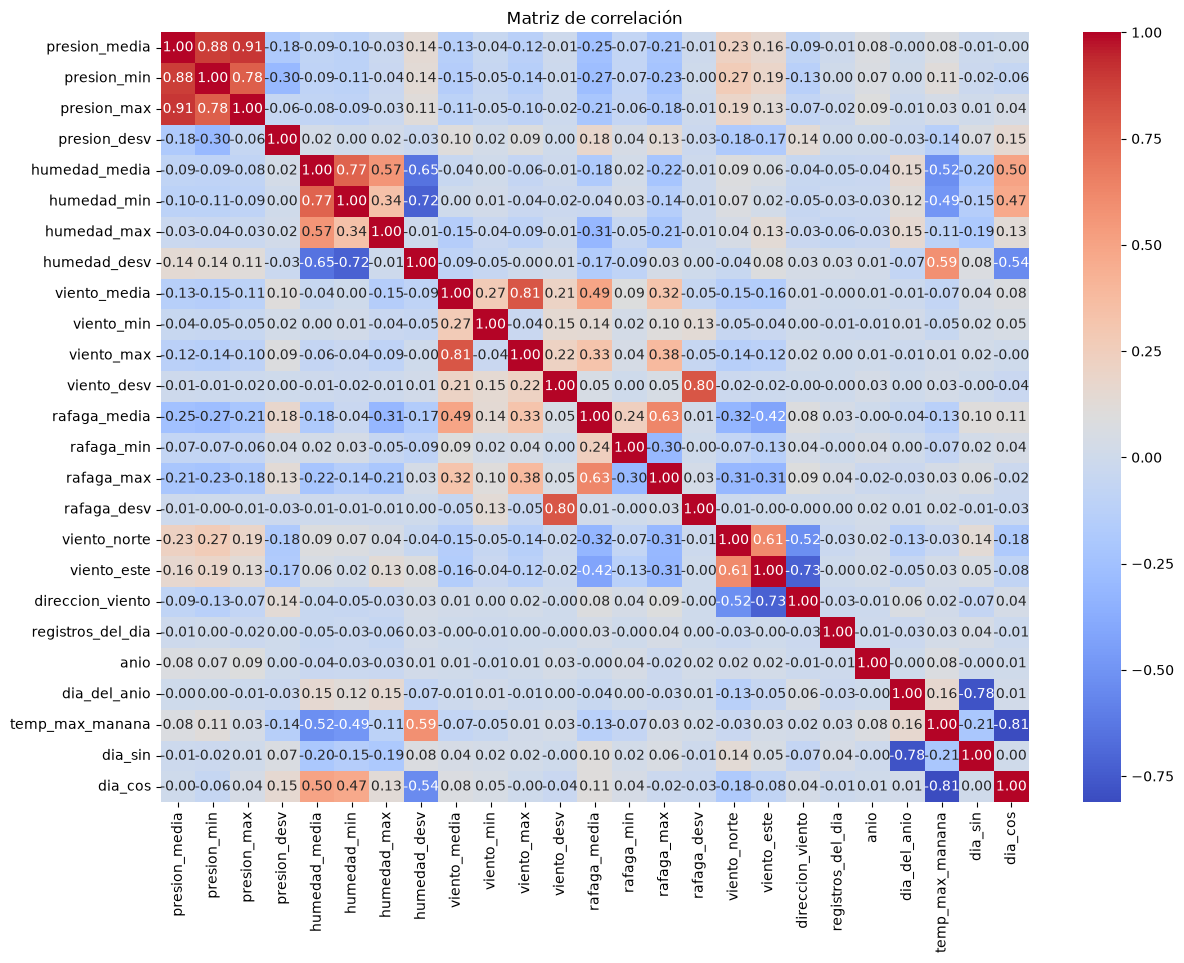

In [317]:
correlaciones = datos.select_dtypes(include="number").corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlaciones, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

Ahora veremos mas claramente las correlaciones con nuestra variable objetivo

In [318]:
correlacion_objetivo = (
    correlaciones["temp_max_manana"]
    .drop("temp_max_manana")
    .sort_values(key=abs, ascending=False)
)

correlacion_objetivo

dia_cos             -0.811715
humedad_desv         0.586988
humedad_media       -0.523867
humedad_min         -0.492354
dia_sin             -0.208018
dia_del_anio         0.164338
presion_desv        -0.138764
rafaga_media        -0.126764
presion_min          0.109848
humedad_max         -0.106120
anio                 0.079797
presion_media        0.079520
viento_media        -0.069839
rafaga_min          -0.068574
viento_min          -0.046507
viento_norte        -0.033815
presion_max          0.031164
rafaga_max           0.030701
viento_desv          0.027927
registros_del_dia    0.027246
viento_este          0.027228
rafaga_desv          0.021206
direccion_viento     0.015755
viento_max           0.013113
Name: temp_max_manana, dtype: float64

## Selección y visualización de variables importantes

Observaremos las variables más correlacionadas con la variable objetivo para entender mejor la relación entre los factores meteorológicos y la temperatura máxima.

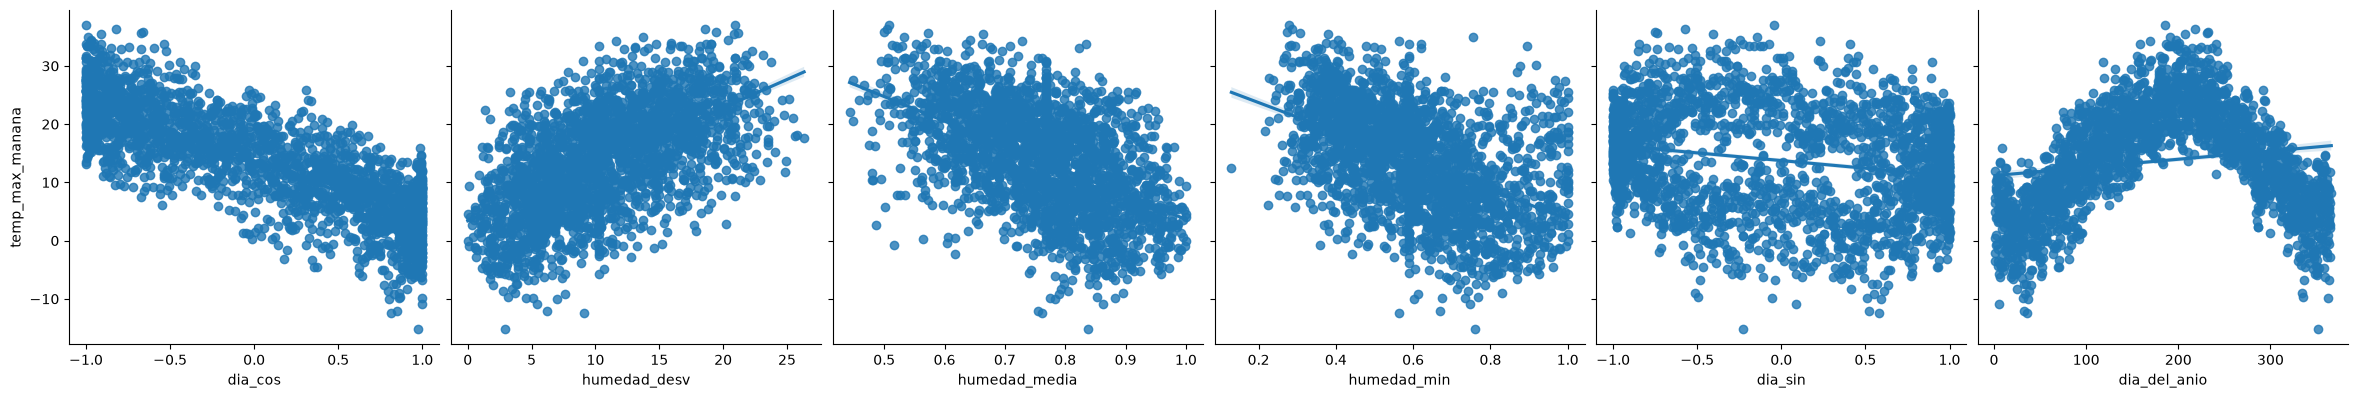

In [319]:
variables_importantes = correlacion_objetivo.abs().head(6).index

sns.pairplot(
    datos,
    x_vars=variables_importantes,
    y_vars="temp_max_manana",
    height=4,
    kind="reg"
)
plt.show()

## Creacion del modelo
Separaremos los datos en entrenamiento y prueba, construimos un pipeline con preprocesamiento y entrenamos un modelo de regresión lineal para predecir la temperatura máxima del día siguiente.

In [320]:
X = datos.drop(columns=["temp_max_manana", "fecha", "anio", "dia_del_anio", "mes", "viento_norte", "viento_este", "registros_del_dia"], errors="ignore")
y = datos["temp_max_manana"]

categoricas = X.select_dtypes(include=["object", "string"]).columns.tolist()
numericas = [c for c in X.columns if c not in categoricas]

preprocesador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categoricas)
    ]
)

modelo = Pipeline([
    ("preprocesamiento", preprocesador),
    ("regresion", LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)


## Evaluación del modelo

Calcularemos las métricas principales del problema de regresión: RMSE, MAE y R². Esto nos permitirá saber qué tan preciso es el modelo predictivo.

In [321]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2:  {r2:.4f}")




RMSE: 4.3115
MAE: 3.4562
R2:  0.7579


## Creacion del Segundo Modelo

Como segunda estrategia de preparación, en vez de usar todas las variables predictoras,
seleccionamos únicamente las variables numéricas con mayor correlación

In [322]:
variables_modelo2 = ["dia_cos", "humedad_desv", "humedad_media", "humedad_min", "dia_sin", "presion_desv", "rafaga_media", "presion_min"]

X2 = datos[variables_modelo2]
y2 = datos["temp_max_manana"]

modelo2 = Pipeline([
    ("escalado", StandardScaler()),
    ("regresion", LinearRegression())
])

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.25, random_state=42
)

modelo2.fit(X2_train, y2_train)
y2_pred = modelo2.predict(X2_test)

## Evaluación del segundo modelo

Calcularemos las métricas principales del problema de regresión: RMSE, MAE y R². Esto nos permitirá saber qué tan preciso es el modelo predictivo.

In [323]:
rmse2 = root_mean_squared_error(y2_test, y2_pred)
mae2 = mean_absolute_error(y2_test, y2_pred)
r2_2 = r2_score(y2_test, y2_pred)

print(f"RMSE: {rmse2:.4f}")
print(f"MAE:  {mae2:.4f}")
print(f"R2:   {r2_2:.4f}")

RMSE: 4.5259
MAE:  3.5917
R2:   0.7333


In [324]:
datos_test_original = pd.read_csv("./data/Datos Test Lab 1.csv")
datos_test = datos_test_original.copy()
datos_test["fecha"] = pd.to_datetime(datos_test["fecha"], format="%d.%m.%Y")

for columna in ["humedad_media", "humedad_max", "humedad_min"]:
    datos_test[columna] = datos_test[columna].where(datos_test[columna] <= 1, datos_test[columna] / 100).clip(upper=1)

for columna in ["presion_media", "presion_max", "presion_min"]:
    datos_test[columna] = np.where((datos_test[columna] < 900) | (datos_test[columna] > 1100), np.nan, datos_test[columna])

for columna in cols_viento:
    datos_test[columna] = pd.to_numeric(datos_test[columna], errors="coerce")
    datos_test.loc[datos_test[columna] <= -100, columna] = np.nan

datos_test["dia_del_anio"] = datos_test["fecha"].dt.dayofyear
datos_test["dia_sin"] = np.sin(2 * np.pi * datos_test["dia_del_anio"] / 365.25)
datos_test["dia_cos"] = np.cos(2 * np.pi * datos_test["dia_del_anio"] / 365.25)

columnas_a_imputar = [c for c in columnas_numericas if c in datos_test.columns]
datos_test[columnas_a_imputar] = datos_test[columnas_a_imputar].fillna(medianas_entrenamiento[columnas_a_imputar])

direccion_calculada_test = (np.degrees(np.arctan2(datos_test["viento_este"], datos_test["viento_norte"])) % 360)
datos_test["direccion_viento"] = datos_test["direccion_viento"].fillna(direccion_calculada_test)
datos_test["sector_viento"] = datos_test["sector_viento"].astype("string").str.strip().str.upper()

X_nuevo = datos_test[X.columns]

predicciones = modelo.predict(X_nuevo)
datos_test_original["temp_max_manana"] = predicciones
datos_test_original.to_csv("./data/Datos Test Lab 1.csv", index=False)

In [325]:
tabla_comparativa = pd.DataFrame({
    "Modelo": ["Modelo 1 (todas las variables)", "Modelo 2 (selección por correlación)"],
    "RMSE": [rmse, rmse2],
    "MAE": [mae, mae2],
    "R2": [r2, r2_2]
})
tabla_comparativa

,Modelo,RMSE,MAE,R2
0,Modelo 1 (todas las variables),4.311528,3.456207,0.757932
1,Modelo 2 (selección por correlación),4.525922,3.591714,0.733259


In [326]:
nombres_categoricas = modelo.named_steps["preprocesamiento"].named_transformers_["cat"].get_feature_names_out(categoricas)
nombres_variables = numericas + list(nombres_categoricas)
coeficientes = modelo.named_steps["regresion"].coef_

tabla_importancia = pd.DataFrame({
    "Variable": nombres_variables,
    "Coeficiente": coeficientes
})
tabla_importancia["Importancia_abs"] = tabla_importancia["Coeficiente"].abs()
tabla_importancia = tabla_importancia.sort_values("Importancia_abs", ascending=False)
tabla_importancia

,Variable,Coeficiente,Importancia_abs
18,dia_cos,-5.951429,5.951429
23,sector_viento_E,2.250675,2.250675
28,sector_viento_S,2.119541,2.119541
26,sector_viento_NO,-2.059921,2.059921
17,dia_sin,-2.040274,2.040274
24,sector_viento_N,-1.833831,1.833831
4,humedad_media,-1.507280,1.507280
27,sector_viento_O,-1.475347,1.475347
19,estacion_anio_invierno,-1.070633,1.070633
29,sector_viento_SE,0.883160,0.883160


## Análisis de resultados
Una vez construido los modelos, deberías estar en capacidad de responder estas preguntas: 

- ¿Cuál fue el valor de los diferentes coeficientes obtenidos en el mejor modelo? 

    RTA/: En el Modelo 1, el coeficiente con mayor peso fue `dia_cos` (-5.95), seguido de `dia_sin` (-2.04) y `humedad_media` (-1.51). Las categorías de `sector_viento`también aportan de forma notable (entre 1.5 y 2.3)

- A partir de la tabla comparativa, ¿cuál modelo ofrece el mejor rendimiento sobre el conjunto test? ¿Qué interpretación puedes darles a los valores obtenidos sobre las métricas de rendimiento? 

    RTA/: El Modelo 1 (RMSE=4.31, MAE=3.46, R^2=0.76) supera al Modelo 2 (RMSE=4.53, MAE=3.59, R^2=0.73). El MAE de 3.46 °C es un error moderado frente a la variación de la temperatura (desviación estándar 9 °C), y el R^2=0.76 indica que el modelo explica un 76% de esa variabilidad usando solo datos meteorológicos del día actual

- ¿Cuáles variables fueron seleccionadas con el modelo seleccionado? A partir de estas, ¿qué interpretación de cara al problema puedes dar? Reflexiona sobre cómo este nuevo conocimiento podría ayudar a tomar decisiones en el contexto del problema. 

    RTA/: Las de mayor peso son la epoca (`dia_sin`/`dia_cos`) y la humedad (`humedad_media`, `humedad_desv`), además del sector del viento. Esto indica que la época del año y la humedad ambiental son los factores más determinantes para anticipar la temperatura máxima

- A partir del contexto y los datos compartidos, ¿cómo representar la regresión lineal de forma matemática? Indique el método utilizado y el proceso para resolverlo. 

    RTA/: El modelo sigue la forma general de una regresión lineal múltiple y calcula la temperatura como un valor base más la suma de cada variable meteorológica multiplicada por un coeficiente, que indica qué tanto y en qué dirección influye esa variable. Los coeficientes se hallaron con mínimos cuadrados. El proceso fue: dividir los datos en entrenamiento y prueba, ajustar el modelo solo con el entrenamiento, y evaluarlo sobre el conjunto de prueba.

- En el ciclo de machine learning ¿Qué tipos de sesgo podría afectar los resultados y por qué? Describe dos tipos de sesgo.

    RTA/: 
    Sesgo de muestreo: los datos son traidos de una única estación meteorológica, por lo que el modelo aprende patrones específicos de ese clima y esa ubicación. Si se aplicara a otra ciudad o región con condiciones climáticas distintas, su desempeño probablemente sería mucho peor
    Sesgo de medición: durante la exploración se encontraron errores de captura en los datos originales. Si estos errores no se hubieran corregido, habrían distorsionado tanto los coeficientes del modelo como sus predicciones

## Uso de IA

- Declaración del uso. Nombre de la herramienta utilizada y tipo de uso (ayuda conceptual, generación inicial de código, explicación teórica, depuración, redacción, etc.).
    
    RTA/: Se hizo uso de la herramienta Claude para la aclaración de cosas conceptuales y funciones de implementacion, identificación de errores en la limpieza de datos, validacion de resultados y evaluación de los modelos

- Prompts utilizados. Se deben documentar los prompts principales, de forma textual o resumida. No es necesario incluir interacciones menores, pero sí aquellas que influyeron directamente en el resultado entregado.
    
    RTA/: Los prompts usados fueron sobre la revisión de errores en la validación de datos atipicos, diagnostico de resultados de las metricas RMSE, MAE y R^2, preguntas de como reducir la colinealidad y como funciona el StandartScale y el diseño de una estrategia para la elaboración del segundo modelo

- Análisis crítico del resultado. El estudiante deberá responder, al menos, a dos de las siguientes preguntas: ¿Qué partes del contenido generado fueron correctas y útiles? ¿Qué errores, imprecisiones o limitaciones se identificaron? ¿Qué decisiones técnicas fueron modificadas respecto a la respuesta de la IAG y por qué? ¿Qué conceptos del curso permitieron evaluar o mejorar la respuesta generada?
    
    RTA/: Se identificaron errores como que se tomaba una copia del dataframe antes de corregir un valor que estaba mal y esto provocaba una sobreescritura y deshacia la limpieza, también detecto valores anomalos en temperaturas de ciertos meses que entraban despues de la limpieza pero que causaban cambios drasticos en las metricas.

    A partir de los consejos dados por la IA se cambio la forma en la que se filtraba temperaturas anomalas, aumentando su criterio de busqueda

- Aportes propios del estudiante. Debe explicitarse claramente: ¿Qué fue desarrollado, modificado o decidido por el estudiante? ¿Qué ajustes se realizaron sobre el código o la explicación original? ¿Qué aprendizajes se obtuvieron del proceso?
    
    RTA/: Nosotros decidimos y desarrollamos todos los puntos a partir de una logica basica, teniendo nuestra idea de lo que queriamos principalmente en los modelos, esto se hiz para despues preguntarle a la IA que errores veia y que areas dejabamos por fuera de nuestra respuesta, despues de esto se realizaban las modificaciones pertinentes para dejar un buen modelos y limpieza de datos. El aprendizaje principal fue el de ejecutar y comparar resultados para detectar errores que no se ven a simple vista o detectar que hay algo que no se tuvo en cuenta